# ISIC 2019 Classification Training (Ultralytics YOLO)

This notebook trains a custom skin-lesion classifier using the ISIC 2019 dataset (multi-class).

**You will need to download the dataset manually** (license + account required).
Set the paths below to point at your local dataset folder before running the prep cell.


In [18]:
from io import BytesIO
from pathlib import Path
import os
import random
import shutil

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from IPython.display import display
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from ultralytics import YOLO

## 2. Dataset Setup

Download ISIC 2019 data and place it locally. Expected raw layout:

**Training**
- `ISIC_2019_Training_Input/` (images)
- `ISIC_2019_Training_GroundTruth.csv` (labels)

**Test**
- `ISIC_2019_Test_Input/` (images)
- `ISIC_2019_Test_GroundTruth.csv` (labels)

Set `RAW_DATA_DIR` to the folder containing those files.

### YOLO Classification Folder Format

Ultralytics YOLO expects classification datasets as folders split by `train/`, `val/`, and `test/`, with one subfolder per class:

```
OUTPUT_DIR/
├── train/
│   ├── AK/
│   ├── BCC/
│   └── ...
├── val/
│   ├── AK/
│   ├── BCC/
│   └── ...
└── test/
    ├── AK/
    ├── BCC/
    └── ...
```

The prep cell below converts the ISIC CSV labels into this folder structure for you.


In [8]:
RAW_DATA_DIR = Path("/Users/juanterven/data/isic2019_raw")
OUTPUT_DIR = Path("/Users/juanterven/data/isic2019_yolo")
SPLIT_SEED = 42
VAL_FRACTION = 0.1
MAX_SAMPLES_PER_CLASS = None  # e.g., 200 for a quick demo
EXCLUDED_LABELS = {"UNK", "unknown", "background"}
EXCLUDED_LABELS_LOWER = {label.lower() for label in EXCLUDED_LABELS}

In [ ]:

def safe_link_or_copy(src: Path, dst: Path) -> None:
    """Create a symlink (or copy) from src to dst, ensuring dst's parent exists."""
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        return
    try:
        os.symlink(src, dst)
    except OSError:
        shutil.copy2(src, dst)


def is_excluded_label(label: str) -> bool:
    """Return True if the label should be ignored (e.g., UNK)."""
    return label.strip().lower() in EXCLUDED_LABELS_LOWER


def drop_unknown_rows(df: pd.DataFrame, class_columns: list[str], split_name: str) -> pd.DataFrame:
    """Drop rows without any known label after filtering class columns."""
    row_sum = df[class_columns].sum(axis=1)
    dropped = int((row_sum == 0).sum())
    if dropped:
        print(f"Dropping {dropped} {split_name} rows without known labels")
    return df.loc[row_sum > 0].copy()


def load_isic_2019_train():
    """Load training images and labels from the ISIC 2019 training CSV."""
    images_dir = RAW_DATA_DIR / "ISIC_2019_Training_Input"
    labels_csv = RAW_DATA_DIR / "ISIC_2019_Training_GroundTruth.csv"
    if not labels_csv.exists():
        raise FileNotFoundError(f"Missing CSV: {labels_csv}")
    df = pd.read_csv(labels_csv)
    class_columns = [col for col in df.columns if col != "image" and not is_excluded_label(col)]
    df = drop_unknown_rows(df, class_columns, "train")
    df["label"] = df[class_columns].idxmax(axis=1)
    df["filename"] = df["image"] + ".jpg"
    return images_dir, df[["filename", "label"]], class_columns


def align_label_columns(df: pd.DataFrame, class_columns: list[str]) -> pd.DataFrame:
    """Align label columns to match the training set class list."""
    extra_columns = [col for col in df.columns if col not in class_columns and col != "image"]
    if extra_columns:
        print(f"Dropping extra label columns in test set: {extra_columns}")
    for column in class_columns:
        if column not in df.columns:
            df[column] = 0
    return df[["image"] + class_columns]


def load_isic_2019_test(class_columns: list[str]):
    """Load test images and labels, aligned to the training class list."""
    images_dir = RAW_DATA_DIR / "ISIC_2019_Test_Input"
    labels_csv = RAW_DATA_DIR / "ISIC_2019_Test_GroundTruth.csv"
    if not labels_csv.exists():
        raise FileNotFoundError(f"Missing CSV: {labels_csv}")
    df = pd.read_csv(labels_csv)
    df = align_label_columns(df, class_columns)
    df = drop_unknown_rows(df, class_columns, "test")
    df["label"] = df[class_columns].idxmax(axis=1)
    df["filename"] = df["image"] + ".jpg"
    return images_dir, df[["filename", "label"]]


def sample_per_class(df, max_samples):
    """Optionally subsample each class to a maximum number of samples."""
    if max_samples is None:
        return df
    return (
        df.groupby("label", group_keys=False)
        .apply(lambda group: group.sample(min(len(group), max_samples), random_state=SPLIT_SEED))
        .reset_index(drop=True)
    )


train_images_dir, train_df, class_columns = load_isic_2019_train()
test_images_dir, test_df = load_isic_2019_test(class_columns)

train_df = sample_per_class(train_df, MAX_SAMPLES_PER_CLASS)
train_df, val_df = train_test_split(
    train_df, test_size=VAL_FRACTION, random_state=SPLIT_SEED, stratify=train_df["label"]
)


def write_split(split_df, split_name, images_dir):
    """Write a dataset split to the YOLO folder structure."""
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"{split_name} split"):
        src = images_dir / row["filename"]
        if not src.exists():
            raise FileNotFoundError(f"Missing image: {src}")
        dst = OUTPUT_DIR / split_name / row["label"] / row["filename"]
        safe_link_or_copy(src, dst)


if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
write_split(train_df, "train", train_images_dir)
write_split(val_df, "val", train_images_dir)
write_split(test_df, "test", test_images_dir)

print("Dataset prepared at", OUTPUT_DIR.resolve())


Dropping extra label columns in test set: ['UNK', 'score_weight', 'validation_weight']
Dropping 2047 test rows without known labels


test split: 100%|██████████| 6191/6191 [00:00<00:00, 16626.83it/s]

Dataset prepared at /Users/juanterven/data/isic2019_yolo


## 3. Train the Classifier

If you do not have a GPU, set `device='cpu'` and reduce the batch size.

### Output Structure

Training outputs are saved under the `runs/` directory (relative to the notebook):

```
runs/
└── isic2019_cls/
    ├── weights/
    │   ├── best.pt
    │   └── last.pt
    ├── results.csv
    └── ...
```

Use `best.pt` for evaluation and inference, or change the run name via `name=...` in the train call.


In [ ]:
model = YOLO("yolo26n-cls.pt")
results = model.train(
    data=str(OUTPUT_DIR),  # path to YOLO-formatted dataset folder
    epochs=100,  # maximum training epochs
    patience=10,  # stop if no improvement for 10 epochs
    imgsz=224,  # input image size
    batch=32,  # batch size
    device="mps",  # "mps" (Apple Silicon), "cpu", or "cuda:0"
    project="runs",  # base output directory
    name="isic2019_cls2"  # run name under project
)


Ultralytics 8.4.2 🚀 Python-3.11.14 torch-2.9.1 MPS (Apple M4 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/juanterven/data/isic2019_yolo, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=isic2019_cls2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=Tr

## 4. Evaluate on the Test Split + Quick Inference

Use the test split created from the labeled data (so ground truth is available). For a CLI-only workflow, you can also run:

```bash
python scripts/classify/test_isic2019.py --model runs/isic2019_cls/weights/best.pt --data data/isic2019_yolo
```


In [5]:
# load trained model
model = YOLO("runs/isic2019_cls/weights/best.pt")

In [ ]:
metrics = model.val(
    data=str(OUTPUT_DIR),
    split="test",
    project="/Users/juanterven/dev/yolo_course/notebooks/runs",
    name="isic2019_eval"
)
print(metrics)


Ultralytics 8.4.2 🚀 Python-3.11.14 torch-2.9.1 CPU (Apple M4 Max)
YOLO26n-cls summary (fused): 47 layers, 1,536,272 parameters, 0 gradients, 3.2 GFLOPs
train: /Users/juanterven/data/isic2019_yolo/train... found 22797 images in 8 classes ✅ 
val: /Users/juanterven/data/isic2019_yolo/val... found 2534 images in 8 classes ✅ 
test: /Users/juanterven/data/isic2019_yolo/test... found 6191 images in 8 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5559.3±2820.4 MB/s, size: 256.9 KB)
test: Scanning /Users/juanterven/data/isic2019_yolo/test... 6191 images, 0 corrupt: 100% ━━━━━━━━━━━━ 6191/6191 2.9Git/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 387/387 4.3it/s 1:29<0.2ss
                   all      0.702      0.986
Speed: 0.0ms preprocess, 8.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /Users/juanterven/dev/yolo_course/notebooks/runs/isic2019_eval
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matr

## 5. Random Test Image + Probabilities

Run this cell to sample a new test image, display it, and print class probabilities.

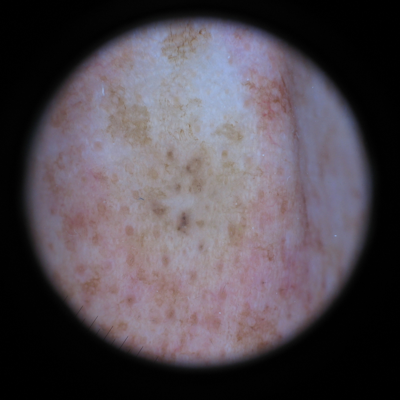

Ground truth: Basal cell carcinoma (BCC)

Prediction probabilities:
  Basal cell carcinoma (BCC): 0.7302
  Actinic keratoses (AK): 0.1450
  Benign keratosis-like lesions (BKL): 0.0628
  Melanoma (MEL): 0.0389
  Melanocytic nevi (NV): 0.0183
  Squamous cell carcinoma (SCC): 0.0045
  Dermatofibroma (DF): 0.0002
  Vascular lesions (VASC): 0.0000


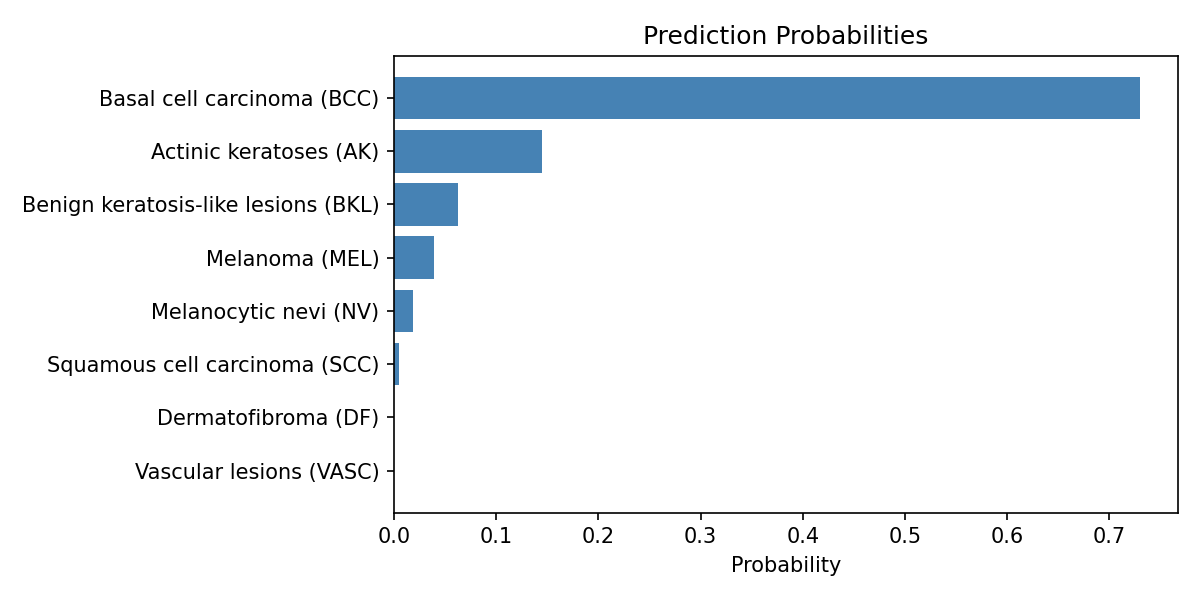

In [30]:
# Pick a random test image each time
random_image = random.choice(list((OUTPUT_DIR / "test").rglob("*.jpg")))

# Display the image (adjust display_width to control size)
image = Image.open(random_image)
display_width = 400
scale = display_width / image.width
image_display = image.resize((display_width, int(image.height * scale)))
display(image_display)

# Run prediction
preds = model.predict(source=str(random_image), verbose=False)
probs = preds[0].probs

if probs is None:
    raise ValueError("No probabilities returned. Ensure you are using a classification model.")

# Map class indices to names
class_names = preds[0].names
scores = probs.data.cpu().numpy()

full_class_names = {
    "AK": "Actinic keratoses",
    "BCC": "Basal cell carcinoma",
    "BKL": "Benign keratosis-like lesions",
    "DF": "Dermatofibroma",
    "MEL": "Melanoma",
    "NV": "Melanocytic nevi",
    "SCC": "Squamous cell carcinoma",
    "VASC": "Vascular lesions",
}

ground_truth_code = random_image.parent.name
ground_truth_name = full_class_names.get(ground_truth_code, ground_truth_code)
print(f"Ground truth: {ground_truth_name} ({ground_truth_code})\n")

sorted_items = sorted(enumerate(scores), key=lambda item: item[1], reverse=True)
labels = []
values = []

print("Prediction probabilities:")
for class_id, score in sorted_items:
    class_code = class_names.get(class_id, str(class_id))
    class_name = full_class_names.get(class_code, class_code)
    labels.append(f"{class_name} ({class_code})")
    values.append(score)
    print(f"  {class_name} ({class_code}): {score:.4f}")

# Horizontal bar chart of probabilities (render as image to ensure display)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(labels, values, color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Probability")
ax.set_title("Prediction Probabilities")
fig.tight_layout()

buffer = BytesIO()
fig.savefig(buffer, format="png", dpi=150)
plt.close(fig)
buffer.seek(0)
display(Image.open(buffer))